# Importing the necessary libraries

In [23]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

from Evaluator import Evaluator
from SegmentationModel import SegmentationModel
from Trainer import Trainer

torch.cuda.empty_cache()

# Configuration parameters

In [24]:
DATA_ROOT = 'train'
BATCH_SIZE = 8
LEARNING_RATE = 0.001
NUM_EPOCHS = 5
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'
SEED = 42  # Seed per la riproducibilità

# Device configuration

In [25]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


In [26]:
from RuralDataset import RuralDataset

dataset = RuralDataset("train")
print("Numero di campioni nel dataset:", len(dataset))
img1 = dataset.__getitem__(1)

Numero di campioni nel dataset: 931


## Transform initialization

In [27]:
transform = transforms.Compose([
        transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

full_dataset = RuralDataset(root_dir=DATA_ROOT, transform=transform)

# Dataset split into training and validation sets

In [28]:
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
# Generatore per la riproducibilità
split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size], generator=split_generator)

def collate_fn_gpu(batch):
    images, labels = zip(*batch)
    images = torch.stack(images).to(device, non_blocking=True)
    labels = torch.stack(labels).to(device, non_blocking=True)
    return images, labels

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=True,
    pin_memory=True)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=False,
    pin_memory=True)


print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")

Training on 744 samples, validating on 187 samples.


# Model initialization

In [29]:
model = SegmentationModel(n_channels = 3, n_classes=NUM_CLASSES)
model.to(device)
print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), 

## Loss function and optimizer definition

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Trainer initialization and training

In [ ]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")


Starting training...

Epoch 1/5
Batch 1/93, Loss: 2.2415
Batch 2/93, Loss: 1.9962
Batch 3/93, Loss: 1.9123
Batch 4/93, Loss: 1.8843
Batch 5/93, Loss: 1.8469
Batch 6/93, Loss: 1.8354
Batch 7/93, Loss: 1.8256
Batch 8/93, Loss: 1.6438


# Final evaluation of the model

In [19]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()

In [20]:
print(metrics.get('accuracy', 'N/A'))
print(metrics.get('f1_score', 'N/A'))
print(metrics.get('precision', 'N/A'))
print(metrics.get('recall', 'N/A'))

0.6710631498640984
N/A
0.45203392201518217
0.44509024111608103


label_rgb shape: (544, 1024, 3) dtype: uint8


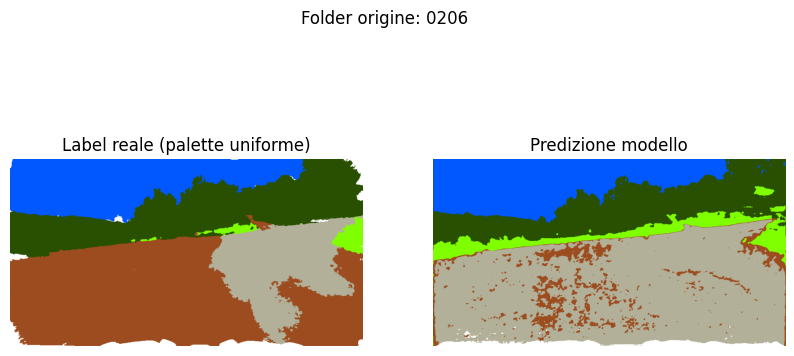

In [21]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
evaluator = Evaluator(model, val_loader, device)
evaluator.compare_random_label_and_prediction(val_dataset)